In [1]:
from src.workloads import Workloads
import configparser
import os
import re
import numpy as np
from src.utils import get_config_as_dict
import matplotlib.pyplot as plt
import csv
import pandas as pd

In [2]:
# Load config with explicit path and typed parsing
config = configparser.ConfigParser()
config_path = os.path.join(os.getcwd(), 'config_file', 'config.ini')
config.read(config_path)
config_dict = get_config_as_dict(config)


In [3]:
WORKLOAD_PATH = "./data/workloads/workload.swf" 






In [4]:
def create_job_df(path):
    rows = []
    with open(path) as fp:
        for line in fp:
            if line.startswith(";"):
                continue
            line = line.strip()
            s_array = re.split(r"\s+", line)
            
            # Append to standard Python lists
            submit_time = int(s_array[1])
            req_processors = int(s_array[4])
            req_run_time = int(s_array[3])

            rows.append({"submit_time": submit_time, "requested_processors": req_processors, "requested_runtime": req_run_time})

    return pd.DataFrame(rows);

In [5]:
def plot_workload_patterns(
    df: pd.DataFrame,
    origin="2021-01-01",
    time_unit="s",                 # "s" if submit_time is in seconds; use "ms" if milliseconds, etc.
    runtime_bins_hours=None,       # custom edges in HOURS; leave None to use fine short bins below
    runtime_clip_q=None            # e.g., 0.995 to clip long tail before binning; or None
):
    need = {"submit_time", "requested_runtime", "requested_processors"}
    miss = need - set(df.columns)
    if miss:
        raise ValueError(f"Missing columns: {sorted(miss)}")

    df = df.copy()
    df["submit_time"] = pd.to_numeric(df["submit_time"], errors="coerce")
    df["requested_runtime"] = pd.to_numeric(df["requested_runtime"], errors="coerce")
    df["requested_processors"] = pd.to_numeric(df["requested_processors"], errors="coerce")
    df = df.dropna(subset=["submit_time"])
    df = df[df["submit_time"] >= 0]

    # Build timestamps from submit_time
    t0 = pd.to_datetime(origin)
    df["timestamp"] = t0 + pd.to_timedelta(df["submit_time"], unit=time_unit)
    df["hour"] = df["timestamp"].dt.hour

    # ---------- Weekly job submissions (avg per weekday) ----------
    per_day = df.set_index("timestamp").resample("D").size().rename("count")
    weekly_avg = (
        per_day.groupby(per_day.index.weekday).mean().reindex(range(7), fill_value=0.0)
    )
    plt.figure()
    plt.bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], weekly_avg.values)
    plt.title("Weekly job submission pattern")
    plt.xlabel("Day of week"); plt.ylabel("Average submissions per day")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Monthly job submissions (avg per day, Jan..Dec across all years) ----------
    # Use resampled daily series so months without submissions still contribute 0 days.
    monthly_avg_per_day = (
        per_day.groupby(per_day.index.month)   # 1..12 across all years
        .mean()
        .reindex(range(1,13), fill_value=0.0)
    )
    plt.figure()
    plt.bar(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
            monthly_avg_per_day.values)
    plt.title("Monthly job submission pattern (average per day)")
    plt.xlabel("Month"); plt.ylabel("Average submissions per day")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Hour-of-day submission pattern (percentage) ----------
    hour_pct = (
        df["hour"].value_counts(normalize=True)
        .reindex(range(24), fill_value=0.0)
        .sort_index() * 100.0
    )
    plt.figure()
    plt.bar(range(24), hour_pct.values)
    plt.title("Hourly job submission pattern")
    plt.xlabel("Hour of day"); plt.ylabel("Percentage of submissions")
    plt.xticks(range(24))
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Job size distribution (processors) ----------
    sizes = df["requested_processors"].dropna()
    sizes = sizes[sizes > 0]
    size_bins = [1, 4, 8, 32, 128, 256, np.inf]
    size_labels = ["1-4", "4-8", "8-32", "32-128", "128-256", "256+"]
    cat = pd.cut(sizes, size_bins, right=False, include_lowest=True, labels=size_labels)
    dist_pct = (cat.value_counts().sort_index() / len(sizes)) * 100.0
    plt.figure()
    plt.bar(dist_pct.index.astype(str), dist_pct.values)
    plt.title("Job size distribution (processors)")
    plt.xlabel("Job size bins"); plt.ylabel("Percentage")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Distribution of requested runtimes (hours) — fine short bins ----------
    rt_h = (df["requested_runtime"].dropna() / 3600.0)
    rt_h = rt_h[rt_h > 0]
    if len(rt_h) == 0:
        plt.figure(); plt.title("Distribution of requested runtimes (hours)")
        plt.text(0.5, 0.5, "No positive runtimes", ha="center"); plt.axis("off"); plt.show()
        return

    if runtime_clip_q:
        rt_h = rt_h.clip(upper=float(rt_h.quantile(runtime_clip_q)))

    # Default: extra-fine bins at short end (minutes), then hour bins
    if runtime_bins_hours is None:
        mins = np.array([0,1, 2, 5, 10, 15, 20, 30, 45, 60]) / 60.0
        hrs  = np.array([2, 4, 8, 12, 24, 48, np.inf], dtype=float)
        runtime_bins_hours = np.concatenate([mins, hrs])

    counts, edges = np.histogram(rt_h.values, bins=runtime_bins_hours)
    pct = counts / counts.sum() * 100.0

    def fmt_h(x):
        return f"{x:.0f}h" if x >= 1 else f"{int(round(x*60))}m"

    labels = []
    for i in range(len(edges)-1):
        lo, hi = edges[i], edges[i+1]
        if np.isinf(hi):
            labels.append(f"{fmt_h(lo)}+")
        else:
            labels.append(f"{fmt_h(lo)}–{fmt_h(hi)}")

    plt.figure()
    plt.bar(labels, pct)
    plt.title("Distribution of requested runtimes (hours)")
    plt.xlabel("Requested runtime bins"); plt.ylabel("Percentage of jobs")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

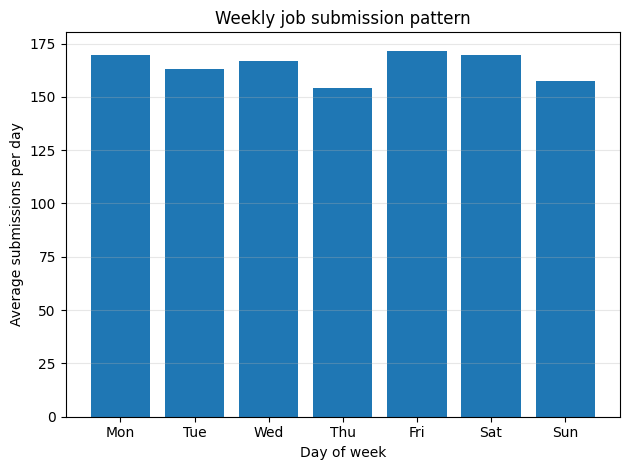

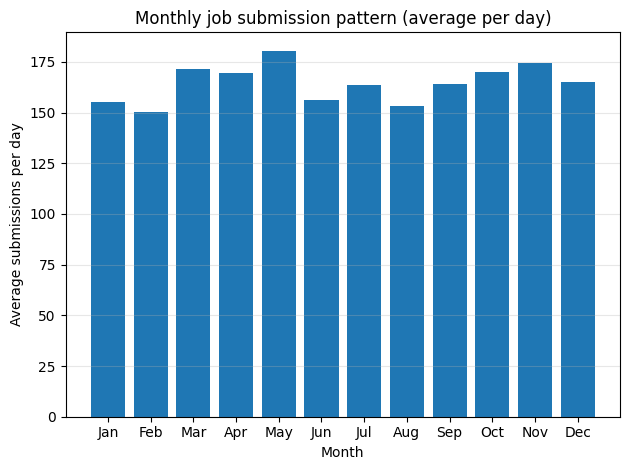

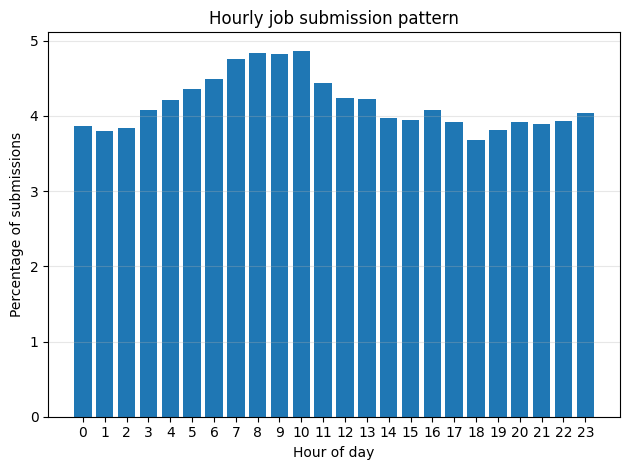

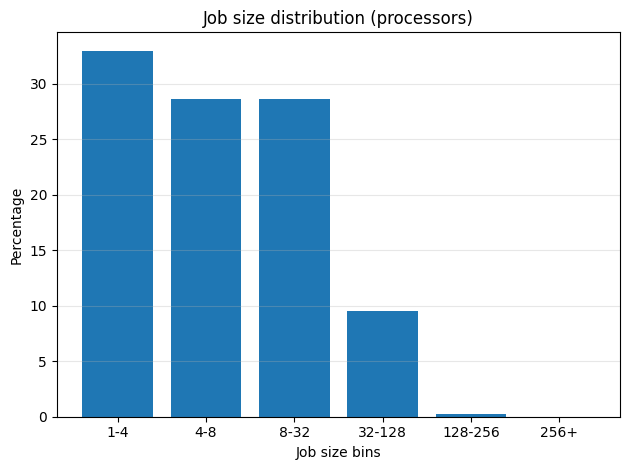

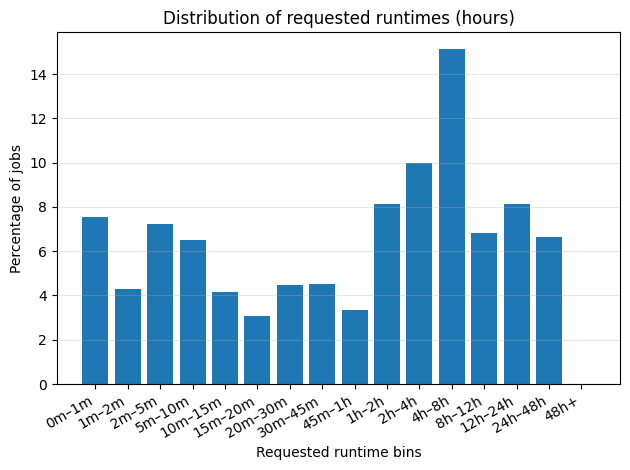

In [6]:
df = create_job_df(WORKLOAD_PATH)
plot_workload_patterns(df)